### Esse é o meu template de uma rede neural usando Pytorch

# 0 - Definir o Problema

In [89]:
## Type of problem
# 0 = Regressão
# 1 = Classificação Binária
# 2 = Classificação com várias classes
# 3 = Classificação com várias classes usando log-softmax
t = 1

# Hyperparameters
LR = 0.01 # Learning Rate
NEPOCH = 100 # Default Num of Epoch if not define different
NUMCLASS = 9 # Number of class used with these data for classification (multiclass problems)
TRAIN_TEST_RATIO = 0.9 # Ratio between Train and Test
BATCH_SIZE = 32 # Size of each batch
SEED = 42 # Seed for reprocibility

# 1 - Carregar as bibliotecas

In [90]:
### import libraries

# for DL modeling
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset

# for number-crunching
import numpy as np

# for dataset management
import pandas as pd

# for print messages
import sys

# for split data in train/test
from sklearn.model_selection import train_test_split

# for data visualization
import matplotlib.pyplot as plt
#import seaborn as sns

# 2 - Obter os dados

In [91]:
def createRegData(m):
  N = 200
  x = torch.linspace(-10,10,N)
  bias = torch.randint(-5,10,(1,))
  y = bias + m*x + torch.randn(N)/5
  return x.unsqueeze(1), y.unsqueeze(1)

In [92]:
def createBinData():
    url  = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
    data = pd.read_csv(url,sep=';')
    
    #data.describe()
       
    print(data['quality'].unique())
    
    # Valores <=4:0 ; Valores >4:1
    data.loc[data.quality <= 4, 'quality' ] = 0
    data.loc[data.quality >  4, 'quality' ] = 1
    
    print(data['quality'].unique())
    
    features = data.iloc[:,:-1]
    labels = data.iloc[:, -1]
        
    return features, labels


In [93]:
def createMultData():
    url  = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
    data = pd.read_csv(url,sep=';')
    
    #data.describe()
    
    print("List of class :", data['quality'].unique())
    print("Number of class must be equal", data["quality"].max() +1)
    
    features = data.iloc[:,:-1]
    labels = data.iloc[:, -1]
       
    return features, labels

In [94]:
# Create data according problem defined
if (t==0):
    features_T, labels_T = createRegData(0.7)
    # show the data
    fig = plt.figure(figsize=(5,5))
    plt.plot(features_T, labels_T)
    plt.show()
    
elif (t==1):
    features, labels = createBinData()
    
    # z-score all columns (mean = zero, std = 1)
    features = (features - features.mean())/features.std(ddof=1)
    
    # Convert to tensor
    features_T = torch.tensor(features.values).float()
    labels_T = torch.tensor(labels.values).float().unsqueeze(1) # stack
    
elif (t==2) or (t==3):
    features, labels = createMultData()
    #features.head()
    
    # z-score all columns (mean = zero, std = 1)
    features = (features - features.mean())/features.std(ddof=1)
    
    # Convert to tensor
    features_T = torch.tensor(features.values).float()
    labels_T = torch.tensor(labels.values).long() # stack
    

[5 6 7 4 8 3]
[1 0]


# 3 - Limpar os dados (Análise Exploratória de Dados)

# 4 - Separar Features de Labels

# 5 - Se necessário, Normalizar os valores

# 6 - Converter para Tensores

# 7 - Separar Treino e Teste

In [95]:

A = len(features_T)
B = TRAIN_TEST_RATIO # rational treino/teste
C = BATCH_SIZE # tamanho do batch

train_size = int(((A*B)//C)*C)

x_train_T, x_test_T, y_train_T, y_test_T = train_test_split(features_T, labels_T,train_size=train_size, random_state=SEED)

In [96]:
x_train_T.shape, x_test_T.shape

(torch.Size([1408, 11]), torch.Size([191, 11]))

# 8 - Criar TensorDatasets para o Treino e Teste

In [97]:
# Create TensorDatasets
train_ds = TensorDataset(x_train_T, y_train_T)
test_ds = TensorDataset(x_test_T, y_test_T)

In [98]:
# check
train_ds.tensors[0].shape[0], test_ds.tensors[0].shape[0]


(1408, 191)

# 9 - Criar DataLoader para Treino e Teste. Treino em pequenos Batches e o Teste em um Batch de tamanho único

In [99]:
# Create DataLoader for train
train_DL = DataLoader(train_ds,batch_size=BATCH_SIZE)

# Create DataLoader for test - just one big Batch
test_DL = DataLoader(test_ds, batch_size=test_ds.tensors[0].shape[0])

In [100]:
# Sanity check
num_data = len(features_T)
num_batch_train = len(train_DL)
num_batch_test = len(test_DL)
num_test = len(test_DL.dataset.tensors[0])

print("Total of data: ", num_data)
print("Batch Size: ", BATCH_SIZE)
print("Number of batchs for training: ", num_batch_train)
print("Number of batchs for test: ", num_batch_test )
print("Number of samples on test: ", num_test)

print("Total data = Batch Size * Num Batch on Train + Num samples on Test: ", BATCH_SIZE * num_batch_train + num_test)


Total of data:  1599
Batch Size:  32
Number of batchs for training:  44
Number of batchs for test:  1
Number of samples on test:  191
Total data = Batch Size * Num Batch on Train + Num samples on Test:  1599


# 10 - Criar uma Classe para o Modelo

In [101]:
### define many classes

class myClass_reg(nn.Module):
  def __init__(self):
    super().__init__()

    ### input layer
    self.input = nn.Linear(1,16) # First number must match with number of features
    
    ### hidden layer
    self.fc1 = nn.Linear(16,32)
    self.fc2 = nn.Linear(32,32)
    
    ### output layer
    self.output = nn.Linear(32,1)

  # forward pass
  def forward(self,x):
    x = F.relu( self.input(x) )
    x = F.relu( self.fc1(x) ) # fully connected
    x = F.relu( self.fc2(x) )
    
    return self.output(x)
  
class myClass_bin(nn.Module):
  def __init__(self):
    super().__init__()

    ### input layer
    self.input = nn.Linear(11,16) # First number must match with number of features
    
    ### hidden layer
    self.fc1 = nn.Linear(16,32)
    self.fc2 = nn.Linear(32,32)
    
    ### output layer
    self.output = nn.Linear(32,1)

  # forward pass
  def forward(self,x):
    x = F.relu( self.input(x) )
    x = F.relu( self.fc1(x) ) # fully connected
    x = F.relu( self.fc2(x) )
    
    return self.output(x)
  
class myClass_mult(nn.Module):
  def __init__(self):
    super().__init__()

    ### input layer
    self.input = nn.Linear(11,16) # First number must match with number of features
    
    ### hidden layer
    self.fc1 = nn.Linear(16,32)
    self.fc2 = nn.Linear(32,32)
    
    ### output layer
    self.output = nn.Linear(32,NUMCLASS) # The last number must match with number of class to be classified

  # forward pass
  def forward(self,x):
    x = F.relu( self.input(x) )
    x = F.relu( self.fc1(x) ) # fully connected
    x = F.relu( self.fc2(x) )
    
    return self.output(x)
  
class myClass_mult_logsftmax(nn.Module):
  def __init__(self):
    super().__init__()

    ### input layer
    self.input = nn.Linear(11,16) # First number must match with number of features
    
    ### hidden layer
    self.fc1 = nn.Linear(16,32)
    self.fc2 = nn.Linear(32,32)
    
    ### output layer
    self.output = nn.Linear(32,NUMCLASS) # The last number must match with number of class to be classified

  # forward pass
  def forward(self,x):
    x = F.relu( self.input(x) )
    x = F.relu( self.fc1(x) ) # fully connected
    x = F.relu( self.fc2(x) )
    
    return torch.log_softmax(self.output(x), axis=1)


# 11 - Testar o modelo com dados ficticios

In [102]:
# Create a model object
if (t==0):
    teste_model = myClass_reg()
    num_feat = 1
elif (t==1):
    teste_model = myClass_bin()
    num_feat = 11
elif (t==2):
    teste_model = myClass_mult()
    num_feat = 11
elif (t==3):
    teste_model = myClass_mult_logsftmax()
    num_feat = (1,11)

# create training data
X = torch.randn(num_feat)

# check the model
print("This is the model: \n",teste_model)
print("This is the input: ", X)
print("This is the result: ",teste_model(X).detach())

This is the model: 
 myClass_bin(
  (input): Linear(in_features=11, out_features=16, bias=True)
  (fc1): Linear(in_features=16, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
)
This is the input:  tensor([-0.3006,  2.5277, -0.9008, -1.0387,  1.3702, -2.3405, -0.4040, -0.0314,
         0.8215,  0.0273, -0.5403])
This is the result:  tensor([0.0285])


In [103]:
X.shape

torch.Size([11])

# 12 - Criar uma função que retorna o Modelo, a Função de Perda (Loss Function) e o Otimizador

In [104]:
# Define a function to return model, loss function and optimizer
def new_model(t):
    """t define the type of model to be used
    0 = regression
    1 = binary classification
    2 = multiclass classification
    3 = multiclass classification using log-softmax"""
    
    if (t==0):
        model = myClass_reg()
        loss_fun = nn.MSELoss()
    
    elif (t==1):
       model = myClass_bin()
       loss_fun = nn.BCEWithLogitsLoss()
    
    elif (t==2):
       model = myClass_mult()
       loss_fun = nn.CrossEntropyLoss()
       
    elif (t==3):
      model = myClass_mult_logsftmax()
      loss_fun = nn.NLLLoss()
        
    # select one option (uncoment the line)
    # optimizer = torch.optim.SGD(model.parameters(),lr=LR)
    optimizer = torch.optim.Adam(model.parameters(),lr=LR)
    
    return model, loss_fun, optimizer

In [105]:
## Test the model with just one batch

# get one batch sample
X, y = next(iter(train_DL))

# create a model with loss function
teste_model, loss_f, _ = new_model(t)

# Test model and loss function
result = teste_model(X)

print("Result shape ", result.shape)
print("Loss function result ", loss_f(result, y).item())
print("Model results ", result )


Result shape  torch.Size([32, 1])
Loss function result  0.5720192790031433
Model results  tensor([[0.4041],
        [0.2714],
        [0.2367],
        [0.2132],
        [0.2363],
        [0.2492],
        [0.2393],
        [0.2099],
        [0.2374],
        [0.2353],
        [0.2267],
        [0.2424],
        [0.2295],
        [0.2409],
        [0.2500],
        [0.2692],
        [0.3532],
        [0.2105],
        [0.3970],
        [0.2470],
        [0.2646],
        [0.2291],
        [0.2278],
        [0.2382],
        [0.2439],
        [0.4685],
        [0.2092],
        [0.2533],
        [0.2652],
        [0.2333],
        [0.2476],
        [0.2388]], grad_fn=<AddmmBackward0>)


# 13 - Criar uma função que treina o Modelo e retorna a perda e acurácia para o treino e teste

In [106]:
# a function that trains the model

def function2trainTheModel(t, numepochs=NEPOCH):
  """t define the type of model to be trained
  0 = regression
  1 = binary classification
  2 = multiclass classification
  3 = multiclass classification with log-softmax
  
  numepochs number of epochs to train, default is 10"""

  def calc_acc(t, yHat, y):
    """Compute accuracy according problem type"""
    if (t == 0): # Regression
      return 100*torch.mean((torch.abs(yHat - y) < 0.5).float()).item()
    
    elif (t == 1): # Binary
      return 100*torch.mean(((yHat>0) == y).float()).item()
    
    elif (t == 2) or (t == 3): # Multiclass
      predlabels = torch.argmax(yHat,axis=1)
      return 100*torch.mean((predlabels == y).float()).item()
      
      
  # create a new model
  model, criterion, optimizer = new_model(t)


  # initialize losses
  losses    = torch.zeros(numepochs,2)
  trainAcc  = []
  testAcc   = []


  # loop over epochs
  for epochi in range(numepochs):
    # switch to train mode
    model.train()

    # loop over training data batches
    batchAcc  = []
    batchLoss = []
    for X,y in train_DL:

      # forward pass and loss
      yHat = model(X)
      loss = criterion(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())

      # compute accuracy
      matches = calc_acc(t, yHat, y)
      batchAcc.append( matches )               # add to list of accuracies
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )

    # and get average losses across the batches
    losses[epochi,0] = np.mean(batchLoss)

    # test accuracy
    # switch to eval mode
    model.eval()
    X,y = next(iter(test_DL)) # extract X,y from test dataloader
    with torch.no_grad(): # deactivates autograd
      yHat = model(X)

    # Compute Test Loss and accuracy
    loss = criterion(yHat,y)
    losses[epochi,1] = loss
    
    matches = calc_acc(t, yHat, y)
    testAcc.append( matches )
    
    # print message
    msg = 'Processed {}/{} epochs'.format(epochi+1,numepochs)
    sys.stdout.write('\r' + msg)
  # end epochs

  # function output
  return trainAcc,testAcc,losses, model

In [107]:
# Exceutar o treino
train_acc, test_acc, losses, model = function2trainTheModel(t, NEPOCH)


Processed 100/100 epochs

# 14 - Exibe o resultado (gráfico) de perda e acurácia para o treino e teste

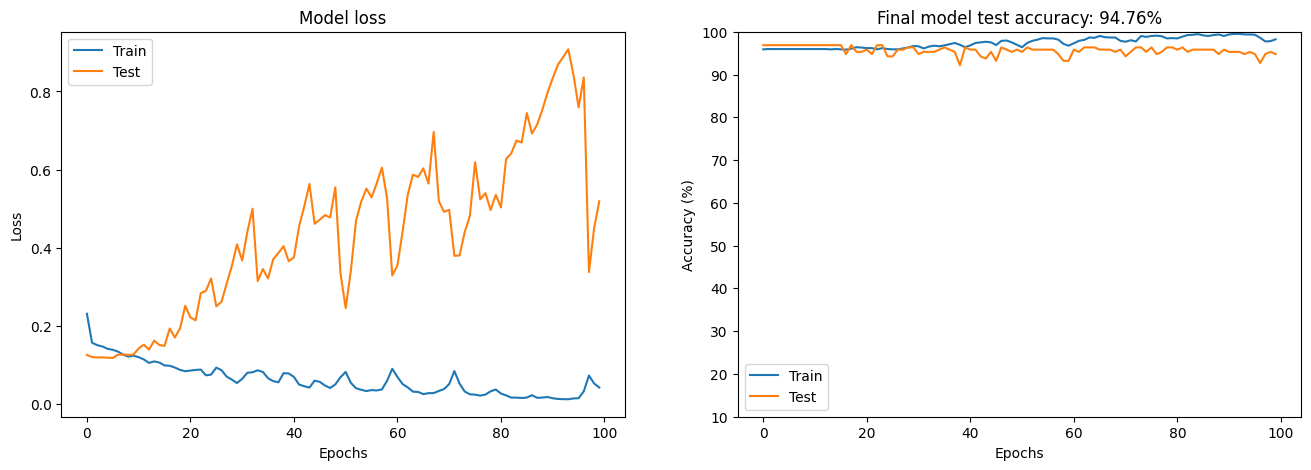

In [108]:
fig,ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(losses)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend(['Train','Test'])
ax[0].set_title('Model loss')

ax[1].plot(train_acc,label='Train')
ax[1].plot(test_acc,label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_ylim([10,100])
ax[1].set_title(f'Final model test accuracy: {test_acc[-1]:.2f}%')
ax[1].legend()

plt.show()

## 15 - Para problema de classificação, exibe os indicadores APRF (Accuracy, Precision, Recall and F1)

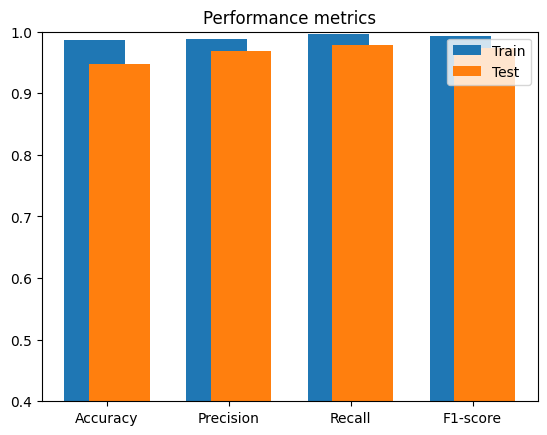

In [109]:
# NEW! using scikitlearn to compute ARPF
import sklearn.metrics as skm

# initialize vectors
train_metrics = [0,0,0,0]
test_metrics  = [0,0,0,0]

# predictions for training and test data
if (t==1):
    train_predictions = model(train_DL.dataset.tensors[0]) # compute with all train data
    
    test_predictions = model(test_DL.dataset.tensors[0]) # compute with all test data
    
    # training
    train_metrics[0] = skm.accuracy_score (train_DL.dataset.tensors[1],train_predictions>0)
    train_metrics[1] = skm.precision_score(train_DL.dataset.tensors[1],train_predictions>0)
    train_metrics[2] = skm.recall_score   (train_DL.dataset.tensors[1],train_predictions>0)
    train_metrics[3] = skm.f1_score       (train_DL.dataset.tensors[1],train_predictions>0)

    # test
    test_metrics[0] = skm.accuracy_score (test_DL.dataset.tensors[1],test_predictions>0)
    test_metrics[1] = skm.precision_score(test_DL.dataset.tensors[1],test_predictions>0)
    test_metrics[2] = skm.recall_score   (test_DL.dataset.tensors[1],test_predictions>0)
    test_metrics[3] = skm.f1_score       (test_DL.dataset.tensors[1],test_predictions>0)
    
if (t==2) or (t==3):
    logits = model(train_DL.dataset.tensors[0]) # compute with all train data
    train_predictions = torch.argmax(logits, axis=1)
    
    logits = model(test_DL.dataset.tensors[0]) # compute with all test data
    test_predictions = torch.argmax(logits, axis=1)
    
    # training
    train_metrics[0] = skm.accuracy_score (train_DL.dataset.tensors[1],train_predictions) # accuracy is overall
    train_metrics[1] = skm.precision_score(train_DL.dataset.tensors[1],train_predictions,average='weighted',zero_division=np.nan)
    train_metrics[2] = skm.recall_score   (train_DL.dataset.tensors[1],train_predictions,average='weighted')
    train_metrics[3] = skm.f1_score       (train_DL.dataset.tensors[1],train_predictions,average='weighted')


    # test
    test_metrics[0] = skm.accuracy_score (test_DL.dataset.tensors[1],test_predictions)
    test_metrics[1] = skm.precision_score(test_DL.dataset.tensors[1],test_predictions,average='weighted',zero_division=np.nan)
    test_metrics[2] = skm.recall_score   (test_DL.dataset.tensors[1],test_predictions,average='weighted')
    test_metrics[3] = skm.f1_score       (test_DL.dataset.tensors[1],test_predictions,average='weighted')



# plot
plt.bar(np.arange(4)-.1,train_metrics,.5)
plt.bar(np.arange(4)+.1,test_metrics,.5)
plt.xticks([0,1,2,3],['Accuracy','Precision','Recall','F1-score'])
plt.ylim([.4,1])
plt.legend(['Train','Test'])
plt.title('Performance metrics')
plt.show()

## 16 - Para problema de regressão mostra os dados reais e do modelo

In [110]:
if (t==0):
    # plot the data
    x = test_DL.dataset.tensors[0]
    y = test_DL.dataset.tensors[1]
    predictions = model(x)
    plt.plot(x,y,'bo',label='Real data')
    plt.plot(x,predictions.detach(),'rs',label='Predictions')
    plt.title(f'prediction-data r={np.corrcoef(y.T,predictions.detach().T)[0,1]:.2f}')
    plt.legend()
    plt.show()